# Taller 04: Descubriendo Patrones Musicales con Spotify Carlos Fernando Gonzalez Sarmiento

## 1. Descripción del Caso
Imagina que trabajas como Data Scientist en una plataforma de streaming musical emergente. El equipo de producto quiere mejorar el sistema de recomendación, pero no tienen etiquetas claras para ciertos tipos de canciones.

Te entregan este conjunto de datos sobre 999 canciones y sus caracteristicas https://www.kaggle.com/datasets/glowstudygram/spotify-songs-and-artists-dataset

El objetivo de la actividad es usar algoritmos de agrupamiento (Clustering) para agrupar las canciones más populares del 2023 basándote únicamente en sus características de audio, ignorando el género o el artista. Luego, deberás interpretar qué representa cada grupo.

## 2. Objetivos de Aprendizaje
* Limpieza de datos.
* Estandarización de variables.
* Reducción de dimensionalidad (PCA).
* Clustering (K-Means o DBScan).
* Interpretación de resultados.

### Bloque 1: Configuración y Carga de Datos
Importa las librerías necesarias y carga el dataset.

In [1]:
# 1. Importación de Librerías
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
import seaborn as sns

In [2]:
ruta_archivo = r"C:\Users\piki_\Downloads\spotifydataset.csv"

df_spotify = pd.read_csv(ruta_archivo)
df_spotify.head()

,Unnamed: 0,artist_name,genres,followers,artist_popularity,artist_url,track_name,album_name,release_date,duration_ms,...,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0,Ariana Grande,pop,98934105,89,https://open.spotify.com/artist/66CXWjxzNUsdJx...,we can't be friends (wait for your love),eternal sunshine,2024-03-08,228639,...,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,1,Ariana Grande,pop,98934105,85,https://open.spotify.com/artist/66CXWjxzNUsdJx...,the boy is mine,eternal sunshine,2024-03-08,173639,...,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,2,Ariana Grande,pop,98934105,83,https://open.spotify.com/artist/66CXWjxzNUsdJx...,intro (end of the world),eternal sunshine,2024-03-08,92400,...,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,3,Ariana Grande,pop,98934105,80,https://open.spotify.com/artist/66CXWjxzNUsdJx...,Save Your Tears (Remix) (with Ariana Grande) -...,After Hours (Deluxe),2020-03-20,191013,...,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,4,Ariana Grande,pop,98934105,79,https://open.spotify.com/artist/66CXWjxzNUsdJx...,"yes, and?",eternal sunshine,2024-03-08,214994,...,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998


### Explicación breve de las columnas de la base

* **track_popularity:** indica qué tan popular es una canción en Spotify. Sus valores van de 0 a 100, donde un valor más alto representa una mayor popularidad.

* **danceability:** representa qué tan apropiada es una canción para bailar. Un valor cercano a 1 indica que la canción es más bailable.

* **energy:** mide qué tan intensa o enérgica se percibe una canción. Los valores altos corresponden a canciones más fuertes, rápidas o activas.

* **key:** representa la tonalidad musical de la canción. Cada número corresponde a una nota musical diferente.

* **loudness:** indica el nivel de volumen general de la canción. Se mide en decibelios y normalmente presenta valores negativos. Los valores más cercanos a cero representan canciones con mayor volumen.

* **mode:** indica si la canción está en modo mayor o menor. El valor 1 representa el modo mayor y el valor 0 representa el modo menor.

* **speechiness:** mide la cantidad de palabras habladas presentes en la canción. Un valor alto puede indicar una mayor presencia de diálogo, rap o contenido hablado.

* **acousticness:** indica qué tan acústica es una canción. Los valores cercanos a 1 representan canciones con mayor presencia de instrumentos acústicos.

* **instrumentalness:** mide qué tan probable es que una canción sea instrumental. Los valores altos indican que la canción tiene poca o ninguna presencia de voz.

* **liveness:** indica la posibilidad de que la canción haya sido grabada en vivo o tenga presencia de público.

* **valence:** representa la sensación positiva o alegre que transmite la canción. Los valores altos corresponden a canciones más alegres, mientras que los valores bajos pueden representar canciones más tristes o serias.

* **tempo:** representa la velocidad o ritmo de la canción. Se mide en pulsaciones por minuto, también conocidas como BPM.


In [ ]:
df_spotify.shape #dimensiones de mi base, no parece que sean 999 porque empieza en 0

(1000, 23)

In [ ]:
df_spotify.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1000 non-null   int64  
 1   artist_name        1000 non-null   object 
 2   genres             837 non-null    object 
 3   followers          1000 non-null   int64  
 4   artist_popularity  1000 non-null   int64  
 5   artist_url         1000 non-null   object 
 6   track_name         1000 non-null   object 
 7   album_name         1000 non-null   object 
 8   release_date       1000 non-null   object 
 9   duration_ms        1000 non-null   int64  
 10  explicit           1000 non-null   bool   
 11  track_popularity   1000 non-null   int64  
 12  danceability       1000 non-null   float64
 13  energy             1000 non-null   float64
 14  key                1000 non-null   int64  
 15  loudness           1000 non-null   float64
 16  mode               1000 n

In [ ]:
df_spotify.isna().sum() #Generos en vacío, tiene sentido

Unnamed: 0             0
artist_name            0
genres               163
followers              0
artist_popularity      0
artist_url             0
track_name             0
album_name             0
release_date           0
duration_ms            0
explicit               0
track_popularity       0
danceability           0
energy                 0
key                    0
loudness               0
mode                   0
speechiness            0
acousticness           0
instrumentalness       0
liveness               0
valence                0
tempo                  0
dtype: int64

In [6]:
df_spotify.isnull().sum()

Unnamed: 0             0
artist_name            0
genres               163
followers              0
artist_popularity      0
artist_url             0
track_name             0
album_name             0
release_date           0
duration_ms            0
explicit               0
track_popularity       0
danceability           0
energy                 0
key                    0
loudness               0
mode                   0
speechiness            0
acousticness           0
instrumentalness       0
liveness               0
valence                0
tempo                  0
dtype: int64

In [ ]:
df_spotify.duplicated().sum() #No existen duplicados en la base completa

0

In [8]:
df_spotify.describe()

,Unnamed: 0,followers,artist_popularity,duration_ms,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,1.150655e+07,59.429000,212368.619000,59.429000,0.611430,0.660562,5.243000,-7.160373,0.613000,0.091402,0.265840,0.074700,0.188810,0.516641,122.143448
std,288.819436,2.293890e+07,23.884963,65706.472572,23.884963,0.167246,0.207568,3.613725,4.479642,0.487307,0.090441,0.288895,0.225472,0.145454,0.232896,28.053658
min,0.000000,2.000000e+00,0.000000,51680.000000,0.000000,0.069000,0.003540,0.000000,-39.482000,0.000000,0.023200,0.000005,0.000000,0.026000,0.032600,49.305000
25%,249.750000,1.038784e+06,57.000000,173083.000000,57.000000,0.505500,0.539500,2.000000,-8.334250,0.000000,0.037975,0.028325,0.000000,0.095700,0.343500,99.983500
50%,499.500000,3.923159e+06,67.000000,204382.500000,67.000000,0.634000,0.680500,5.000000,-5.943500,1.000000,0.054800,0.152500,0.000004,0.129000,0.522000,122.073500
75%,749.250000,1.142132e+07,74.000000,244192.750000,74.000000,0.728250,0.820000,9.000000,-4.582500,1.000000,0.106000,0.416250,0.000586,0.246500,0.686250,138.667250
max,999.000000,1.194287e+08,92.000000,707160.000000,92.000000,0.964000,0.998000,11.000000,0.273000,1.000000,0.874000,0.996000,0.972000,0.984000,0.973000,201.776000


### Bloque 2: Limpieza y Preparación
Se debe trabajar solamente con las columnas que describen como es la canción en terminos auditivos:

- track_popularity
- danceability
- energy
- key
- loudness
- mode
- speechiness
- acousticness
- instrumentalness
- liveness
- valence
- tempo

No se deben usar columnas como el artista o genero para evitar sesgos en la agrupación

In [ ]:
columnas_describen = [
    "track_popularity",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

df_spotifyd = df_spotify[columnas_describen].copy() #Seleccionamos las columnas solicitadas que describen la base
df_spotifyd.head()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,89,0.645,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,85,0.795,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,83,0.506,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,80,0.650,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,79,0.787,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998


In [ ]:
df_spotifyd.shape #Se redujo la base a 12 columnas

(1000, 12)

In [ ]:
df_spotifyd.info() #Todas las columnas son de tipo numerico

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_popularity  1000 non-null   int64  
 1   danceability      1000 non-null   float64
 2   energy            1000 non-null   float64
 3   key               1000 non-null   int64  
 4   loudness          1000 non-null   float64
 5   mode              1000 non-null   int64  
 6   speechiness       1000 non-null   float64
 7   acousticness      1000 non-null   float64
 8   instrumentalness  1000 non-null   float64
 9   liveness          1000 non-null   float64
 10  valence           1000 non-null   float64
 11  tempo             1000 non-null   float64
dtypes: float64(9), int64(3)
memory usage: 93.9 KB


In [ ]:
df_spotifyd.isna().sum() # Sin ninguna columna nula

track_popularity    0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
dtype: int64

In [ ]:
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(df_spotifyd) #Se estandarizan los datos para poderlos trabajar

### Bloque 3: Reducción de Dimensionalidad (PCA)
Reduce los datos a 2 componentes principales para poder visualizarlos en un gráfico 2D.

In [ ]:
pca = PCA(n_components=2) # Seleccionamos dos componenetes principales como se solicita
datos_pca = pca.fit_transform(datos_escalados)

In [17]:
datos_pca.shape

(1000, 2)

In [15]:
print(
    "Varianza explicada acumulada:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

Varianza explicada acumulada: 37.68 %


#### Se aplicó el PCA para reducir las 12 variables usadas a dos componenetes principales, los cuales terminaron explicando el 37,68% de la varianza total, representa mas de 1/4 de la varianza.

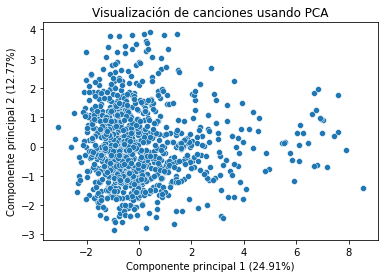

In [16]:
plt.figure(figsize=(6, 4))

sns.scatterplot(
    x=datos_pca[:, 0],
    y=datos_pca[:, 1]
)

plt.title("Visualización de canciones usando PCA")
plt.xlabel(
    f"Componente principal 1 "
    f"({pca.explained_variance_ratio_[0] * 100:.2f}%)"
)
plt.ylabel(
    f"Componente principal 2 "
    f"({pca.explained_variance_ratio_[1] * 100:.2f}%)"
)

plt.show()

### Bloque 4: Modelado (Usa K-Means o DB Scan para generar los clusters)

##### Me voy con k-means

In [ ]:
inercias = []
rango_k = range(1, 11)# Elijo un maximo de 11

for k in rango_k:
    modelo = KMeans(
        n_clusters=k,
        random_state=42
    )

    modelo.fit(datos_pca)
    inercias.append(modelo.inertia_)

c:\Users\piki_\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


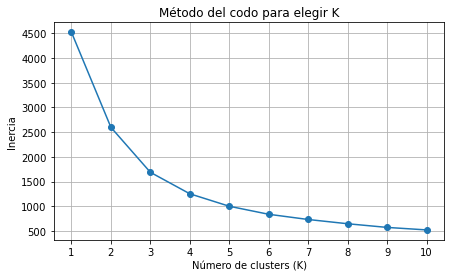

In [19]:
plt.figure(figsize=(7, 4))

plt.plot(
    rango_k,
    inercias,
    marker="o"
)

plt.title("Método del codo para elegir K")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.xticks(rango_k)
plt.grid()

plt.show()

##### Si nos concentramos bien en la grafica podemos evidenciar que el k mas apropiado o que mejor representa el codo es el 3 debido a que es cuando empieza a tener menor diferencia vs el siguiente cluster en la inercia, no es tan abrupta la disminución en la inercia

In [ ]:
kmeans = KMeans(
    n_clusters=3, #elijo 3 clusters
    random_state=42
)

labels_kmeans = kmeans.fit_predict(datos_pca)

In [ ]:
pd.Series(labels_kmeans).value_counts().sort_index() #recuento de valores en mis clusters

0    524
1    139
2    337
dtype: int64

### Bloque 5: Visualización y Análisis
Genera visualizaciones que permitan interpretar qué significa cada grupo.

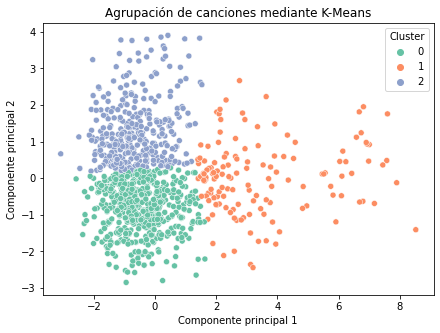

In [23]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=datos_pca[:, 0],
    y=datos_pca[:, 1],
    hue=labels_kmeans,
    palette="Set2",

)

plt.title("Agrupación de canciones mediante K-Means")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend(title="Cluster")

plt.show()

In [ ]:
df_resultado = df_spotifyd.copy()
df_resultado["Cluster"] = labels_kmeans
df_resultado.head()
#Agrego mi numero de cluster a la base de 12 columnas para poder identificar las caracteristicas de los clusters

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,Cluster
0,89,0.645,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842,0
1,85,0.795,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998,0
2,83,0.506,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726,1
3,80,0.650,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091,0
4,79,0.787,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998,0


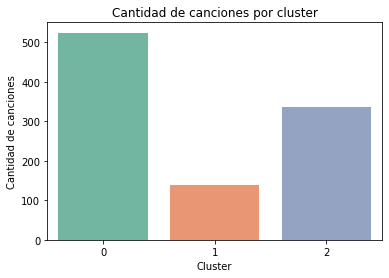

In [28]:
cantidad_clusters = (
    df_resultado["Cluster"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_resultado,
    x="Cluster",
    palette="Set2"
)

plt.title("Cantidad de canciones por cluster")
plt.xlabel("Cluster")
plt.ylabel("Cantidad de canciones")

plt.show()

##### Como vemos aunque ya se había visto arriba el cluster que mas canciones tiene es el cluster 0 y luego el 2

In [ ]:
perfil_clusters = (
    df_resultado
    .groupby("Cluster")
    .mean()
    .round(3)
)

perfil_clusters

# Promedio variables por agrupacion de clusters

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
Cluster,,,,,,,,,,,,
0,65.832,0.708,0.663,5.544,-6.459,0.510,0.104,0.256,0.003,0.153,0.618,113.899
1,45.158,0.463,0.316,5.237,-14.547,0.698,0.054,0.723,0.371,0.133,0.325,117.382
2,55.359,0.522,0.799,4.777,-5.204,0.739,0.087,0.092,0.063,0.267,0.438,136.927


In [ ]:
df_escalado_cluster = pd.DataFrame( #Traemos las variables del df que anteriormente estandarizamos e incluimos el cluster
    datos_escalados,
    columns=columnas_describen,
    index=df_spotifyd.index
)

df_escalado_cluster["Cluster"] = labels_kmeans 

In [ ]:
perfil_estandarizado = (
    df_escalado_cluster
    .groupby("Cluster")
    .mean()
)

perfil_estandarizado
# Promedios de las variables agrupados para cada cluster

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
Cluster,,,,,,,,,,,,
0,0.268213,0.578752,0.011612,0.083306,0.156680,-0.212412,0.138768,-0.032897,-0.316513,-0.244327,0.436497,-0.294039
1,-0.597776,-0.887896,-1.660024,-0.001548,-1.649868,0.174190,-0.415817,1.584941,1.316015,-0.387069,-0.824598,-0.169824
2,-0.170483,-0.533675,0.666642,-0.128893,0.436888,0.258431,-0.044261,-0.602578,-0.050663,0.539554,-0.338591,0.527246


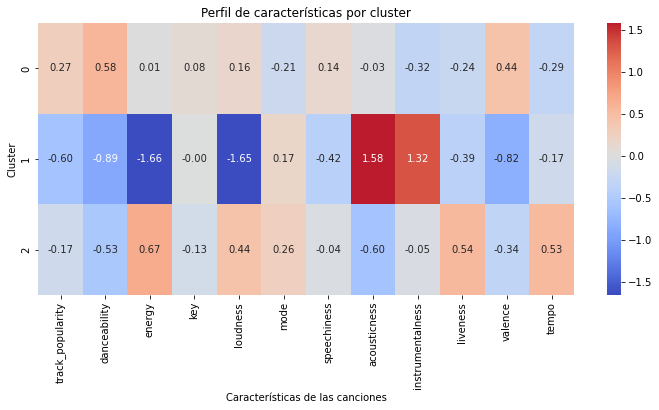

In [32]:
plt.figure(figsize=(12, 5))

sns.heatmap(
    perfil_estandarizado,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Perfil de características por cluster")
plt.xlabel("Características de las canciones")
plt.ylabel("Cluster")

plt.show()

#### Saquemos conclusiones del mapa de calor

* **Cluster 0**: Se caracteriza por tener canciones apropiadas para bailar superirores al promedio (danceability), las canciones representan una sensación positiva (valence), indica que las canciones posee una instrumentalidad menor al promedio (instrumentalness)

* **Cluster 1**: Se caracteriza por tener canciones poco intensas o poco energicas (energy), las canciones indican un volumen mas bajo que el promedio (loudness), las canciones poseen mayor presencia de instrumentos acusticos que el promedio (acousticness), indica que las canciones posee mayor presencia de instrumentales que el promedio (instrumentalness)

* **Cluster 2**: Se caracteriza por tener canciones bastante intensas o mas energicas que el promedio (energy), las canciones poseen menor presencia de instrumentos acusticos que el promedio (acousticness), las canciones indican mayor posibilidad de que hayan sido grabadas en vivo frente al promedio (liveness), las canciones se caracterizan por ser canciones menos bailables o apropiadas para bailar que el promedio (danceability)

### Conclusiones

Plantear 3 conclusiones propias basadas en los resultados obtenidos

## Conclusiones

1. El algoritmo K-Means permitió identificar tres tipos de canciones con características diferentes. El cluster 0 agrupa principalmente canciones más bailables y positivas; el cluster 1 reúne canciones más tranquilas, acústicas e instrumentales; y el cluster 2 contiene canciones más enérgicas, rápidas y con mayor presencia de características asociadas a grabaciones en vivo.

2. En el gráfico de dispersión se observa que el cluster 1 presenta una separación más clara con respecto a los otros grupos, lo que indica que sus canciones tienen un perfil auditivo bastante diferente. Por otro lado, los clusters 0 y 2 se encuentran más cercanos y presentan cierto nivel de superposición, aunque se diferencian principalmente por su ubicación vertical en el gráfico.

3. Los resultados obtenidos pueden ser útiles para crear recomendaciones musicales basadas en la forma en que suenan las canciones, sin depender del artista o del género. Por ejemplo, se podrían recomendar canciones bailables y alegres, canciones acústicas y tranquilas o canciones rápidas y enérgicas según las preferencias del usuario.

4. Aunque el gráfico permite observar la distribución de los clusters, las dos componentes principales explican el 37,68 % de la variabilidad total. Por esta razón, el mapa de calor también fue necesario para interpretar con mayor detalle las características de cada grupo.